In [1]:
import sys
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Add parent directories to path
sys.path.insert(0, os.path.join(os.getcwd(), '..', 'parameters'))
sys.path.insert(0, os.getcwd())

from analysis_utils import (
    load_best_runs,
    load_top_n_runs,
    load_all_runs,
    extract_history,
    add_wall_times,
    build_summary_dataframe,
    plot_convergence_heatmap,
    plot_efficiency_scatter,
    plot_ranking_bar,
    plot_convergence_curves,
    plot_multi_function_performance,
    plot_hp_sensitivity,
    print_convergence_summary,
    print_best_hyperparameters,
    save_best_hyperparameters,
    print_ranking_table,
    print_variant_comparison,
    print_variant_comparison_allruns,
    print_hp_sensitivity_table,
    print_offdiag_ranking,
    get_optimizer_colors,
    ALL_OPTIMIZERS,
    # Budget-aware statistical methods
    bootstrap_best_run_ci,
    print_topk_comparison,
    print_robustness_table,
    plot_best_of_budget,
)

plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

from analysis_utils import (
    plot_diagnostic_curves,
    plot_effective_lr_comparison,
    DIAG_KEYS_METRIC_SCALE,
    DIAG_KEYS_LEARNABLE,
    DIAG_KEYS_CURVATURE,
    DIAG_KEYS_TRAINING,
    DIAG_KEYS_OFFDIAG,
)

# Configuration


In [2]:
# Backend: "wandb" or "local"
BACKEND = "local"

# WandB settings (ignored if BACKEND == "local")
PROJECT = "induced_metric"
ENTITY = "thomas_harvey"

# Results directory (for local backend)
RESULTS_DIR = os.path.join('..', '..', 'results')

# Test functions to analyse
FUNCTIONS = ['beale', 'rosenbrock', 'himmelblau', 'ackley', 'rastrigin']

# Auto-detect which optimizers have results for at least one function
if BACKEND == "local":
    _available = set()
    for func_name in FUNCTIONS:
        task_dir = os.path.join(RESULTS_DIR, f"small_examples_{func_name}")
        if os.path.isdir(task_dir):
            _available.update(os.listdir(task_dir))
    # Keep the canonical ordering from ALL_OPTIMIZERS
    OPTIMIZERS = [o for o in ALL_OPTIMIZERS if o in _available]
else:
    OPTIMIZERS = ALL_OPTIMIZERS

# Iteration/batch number to load results from
ITERATION = 3

colors = get_optimizer_colors(OPTIMIZERS)
print(f"Backend: {BACKEND}")
print(f"Results dir: {RESULTS_DIR}")
print(f"Functions: {FUNCTIONS}")
print(f"Iteration: {ITERATION}")
print(f"Optimizers ({len(OPTIMIZERS)}): {OPTIMIZERS}")

Backend: local
Results dir: ../../results
Functions: ['beale', 'rosenbrock', 'himmelblau', 'ackley', 'rastrigin']
Iteration: 3
Optimizers (28): ['adam', 'adamw', 'sgd', 'muon', 'sgd_metric', 'sgd_log_metric', 'sgd_rms', 'sgd_learn_scalar', 'sgd_learn_scalar_log', 'sgd_learn_diag', 'sgd_learn_diag_log', 'sgd_learn_diag_curv', 'sgd_learn_diag_curv_log', 'sgd_offdiag_0_l', 'sgd_offdiag_0_m', 'sgd_offdiag_0_theta', 'sgd_offdiag_l_0', 'sgd_offdiag_l_l', 'sgd_offdiag_l_m', 'sgd_offdiag_l_theta', 'sgd_offdiag_m_0', 'sgd_offdiag_m_l', 'sgd_offdiag_m_m', 'sgd_offdiag_m_theta', 'sgd_offdiag_theta_0', 'sgd_offdiag_theta_l', 'sgd_offdiag_theta_m', 'sgd_offdiag_theta_theta']


# Load Results


In [3]:
# Load best runs for each function
all_best_runs = {}
for func_name in FUNCTIONS:
    task_tag = f"small_examples_{func_name}"
    print(f"\n--- {func_name.upper()} ---")

    best_runs = load_best_runs(
        backend=BACKEND,
        optimizers=OPTIMIZERS,
        task_tag=task_tag,
        project=PROJECT,
        entity=ENTITY,
        results_dir=RESULTS_DIR,
        metric_key="sweep_metric",
        direction="minimize",
        sort_metric="sweep_metric",
        sort_order="+",
        iteration=ITERATION,
    )
    all_best_runs[func_name] = best_runs

print(f"\nLoaded results for {len(all_best_runs)} functions")
for func_name, runs in all_best_runs.items():
    print(f"  {func_name}: {len(runs)} optimizers")


--- BEALE ---
Finding best run for adam...


  adam: run_1629
Finding best run for adamw...


  adamw: run_3114
Finding best run for sgd...


  sgd: run_649
Finding best run for muon...


  muon: run_4117
Finding best run for sgd_metric...


...

  sgd_offdiag_m_theta: run_3415
Finding best run for sgd_offdiag_theta_0...


  sgd_offdiag_theta_0: run_1877
Finding best run for sgd_offdiag_theta_l...


  sgd_offdiag_theta_l: run_1711
Finding best run for sgd_offdiag_theta_m...


  sgd_offdiag_theta_m: run_3415
Finding best run for sgd_offdiag_theta_theta...


  sgd_offdiag_theta_theta: run_3844

Loaded results for 5 functions
  beale: 28 optimizers
  rosenbrock: 28 optimizers
  himmelblau: 28 optimizers
  ackley: 28 optimizers
  rastrigin: 28 optimizers


In [4]:
# Extract history data for all functions
all_history_data = {}
for func_name in FUNCTIONS:
    best_runs = all_best_runs[func_name]
    if not best_runs:
        continue
    history_data = extract_history(
        BACKEND, best_runs, ["function_value", "runtime_seconds"]
    )
    add_wall_times(history_data, time_key="runtime_seconds")
    all_history_data[func_name] = history_data

# Build summary dataframe
summary_df = build_summary_dataframe(all_best_runs, optimizers=OPTIMIZERS)

print(f"Extracted history for {len(all_history_data)} functions")
print(f"Summary dataframe: {len(summary_df)} rows")

Processing adam...
Processing adamw...
Processing sgd...
Processing muon...
Processing sgd_metric...
Processing sgd_log_metric...
Processing sgd_rms...
Processing sgd_learn_scalar...
Processing sgd_learn_scalar_log...
Processing sgd_learn_diag...
Processing sgd_learn_diag_log...
Processing sgd_learn_diag_curv...
Processing sgd_learn_diag_curv_log...
Processing sgd_offdiag_0_l...
Processing sgd_offdiag_0_m...
Processing sgd_offdiag_0_theta...
Processing sgd_offdiag_l_0...
Processing sgd_offdiag_l_l...
Processing sgd_offdiag_l_m...
Processing sgd_offdiag_l_theta...
Processing sgd_offdiag_m_0...
Processing sgd_offdiag_m_l...
Processing sgd_offdiag_m_m...
Processing sgd_offdiag_m_theta...
Processing sgd_offdiag_theta_0...
Processing sgd_offdiag_theta_l...
Processing sgd_offdiag_theta_m...
Processing sgd_offdiag_theta_theta...
Processing adam...
Processing adamw...
Processing sgd...
Processing muon...
Processing sgd_metric...
Processing sgd_log_metric...
Processing sgd_rms...
Processing sgd

# Performance Comparison


In [5]:
if len(summary_df) == 0:
    print("No results found. Check RESULTS_DIR and ITERATION settings.")
else:
    print(f"Total results: {len(summary_df)}")
    print(f"Convergence rate: {summary_df['converged'].mean():.1%}")

    print("\nConvergence by optimizer:")
    conv = summary_df.groupby('optimizer')['converged'].agg(['count', 'sum', 'mean'])
    conv.columns = ['runs', 'converged', 'rate']
    print(conv.to_string())

Total results: 140
Convergence rate: 95.0%

Convergence by optimizer:
                         runs  converged  rate
optimizer                                     
adam                        5          4   0.8
adamw                       5          4   0.8
sgd                         5          4   0.8
muon                        5          4   0.8
sgd_metric                  5          5   1.0
sgd_log_metric              5          5   1.0
sgd_rms                     5          4   0.8
sgd_learn_scalar            5          5   1.0
sgd_learn_scalar_log        5          5   1.0
sgd_learn_diag              5          4   0.8
sgd_learn_diag_log          5          5   1.0
sgd_learn_diag_curv         5          5   1.0
sgd_learn_diag_curv_log     5          5   1.0
sgd_offdiag_0_l             5          5   1.0
sgd_offdiag_0_m             5          5   1.0
sgd_offdiag_0_theta         5          5   1.0
sgd_offdiag_l_0             5          5   1.0
sgd_offdiag_l_l             5        

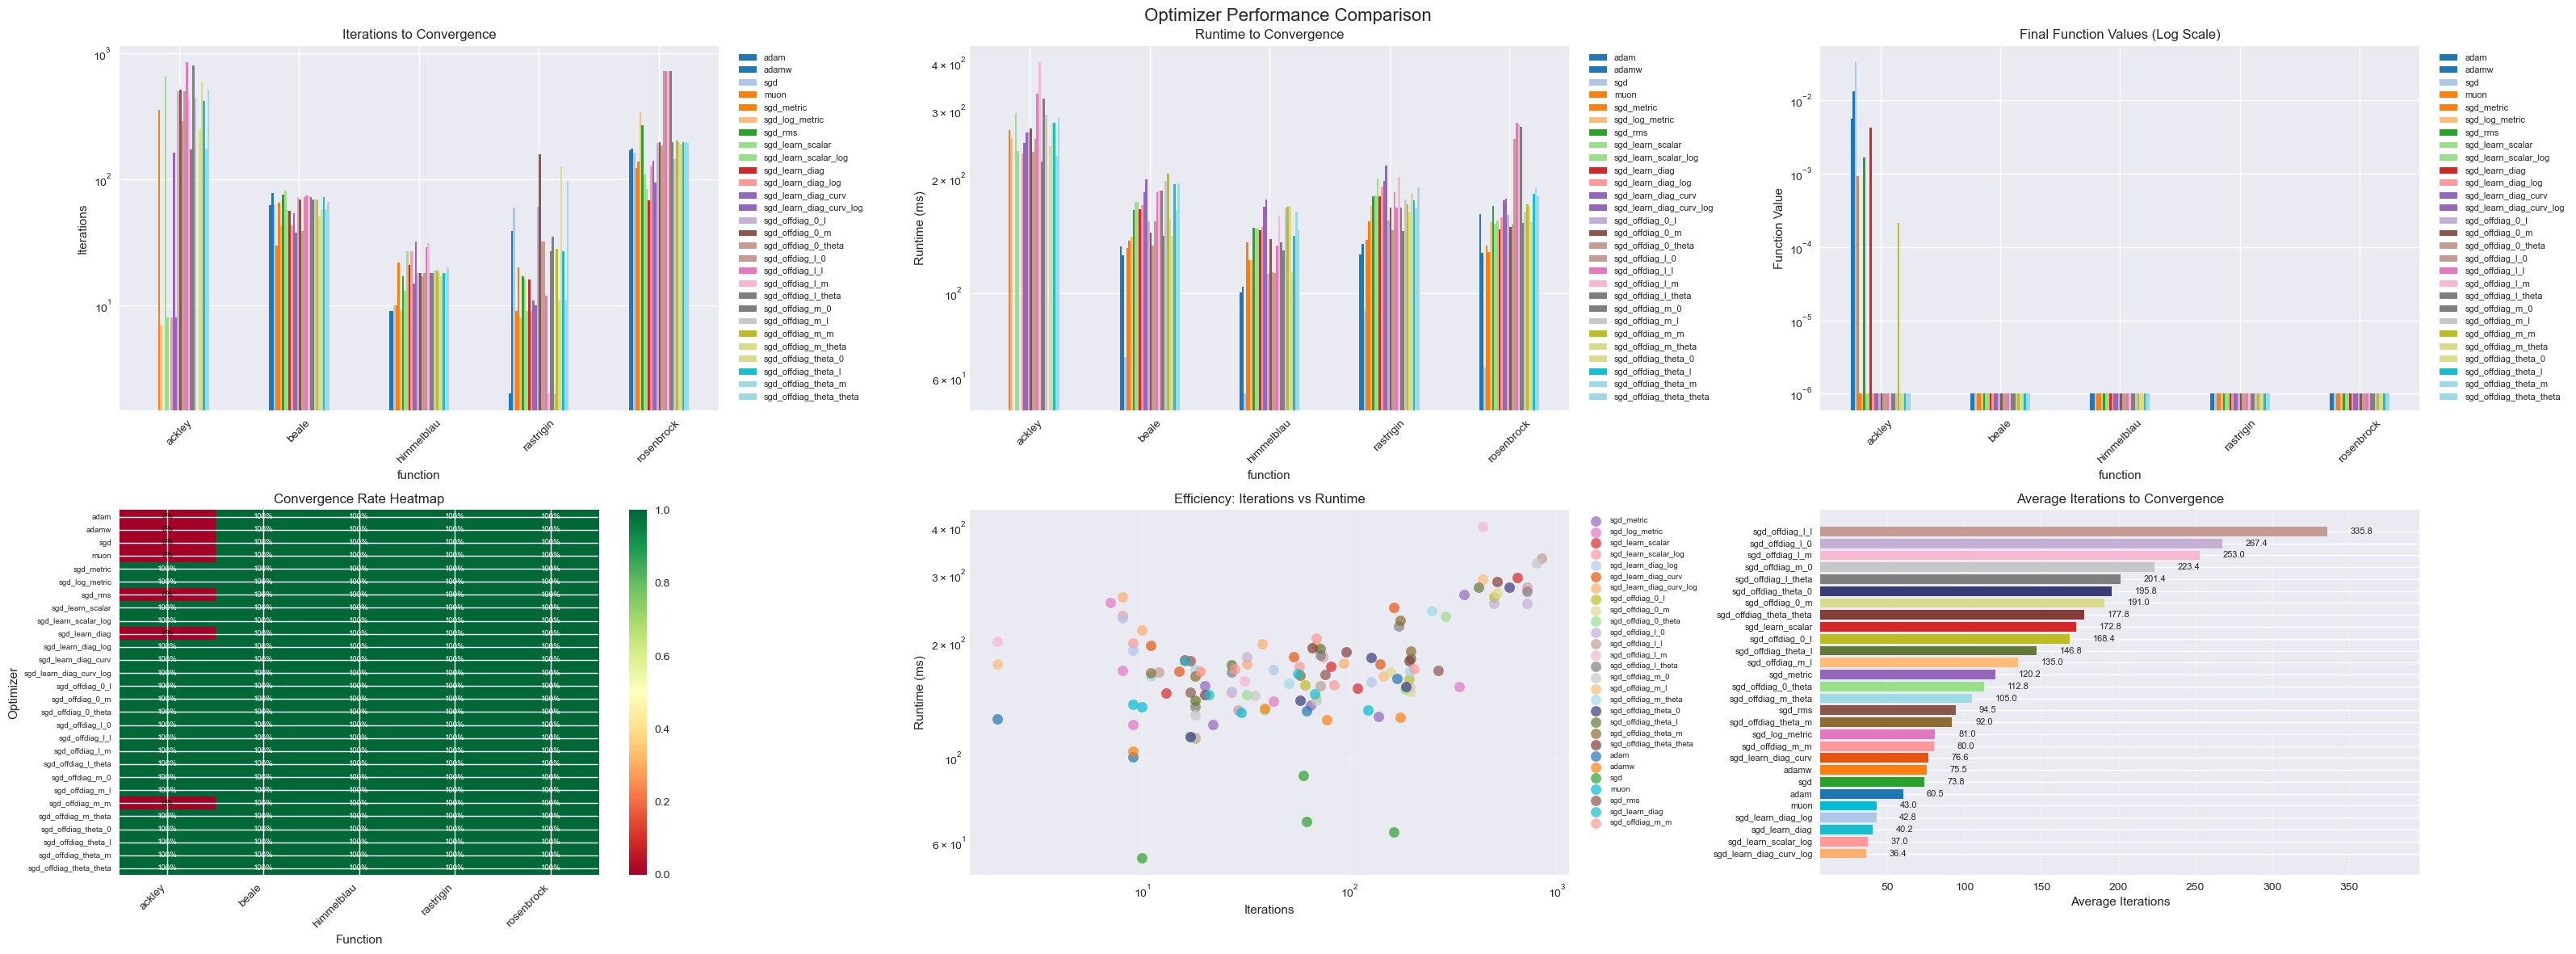

In [6]:
if len(summary_df) == 0:
    print("No results to plot.")
else:
    fig = plot_multi_function_performance(summary_df)
    plt.show()

# Convergence Curves


/Users/noah-everett/Library/Mobile Documents/com~apple~CloudDocs/Projects/induced-metric-optimiser/repo/analysis/plots.py:422: UserWarning: Glyph 10003 (\N{CHECK MARK}) missing from font(s) Arial.
  plt.tight_layout()
/Users/noah-everett/Library/Mobile Documents/com~apple~CloudDocs/Projects/induced-metric-optimiser/.conda/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 10003 (\N{CHECK MARK}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


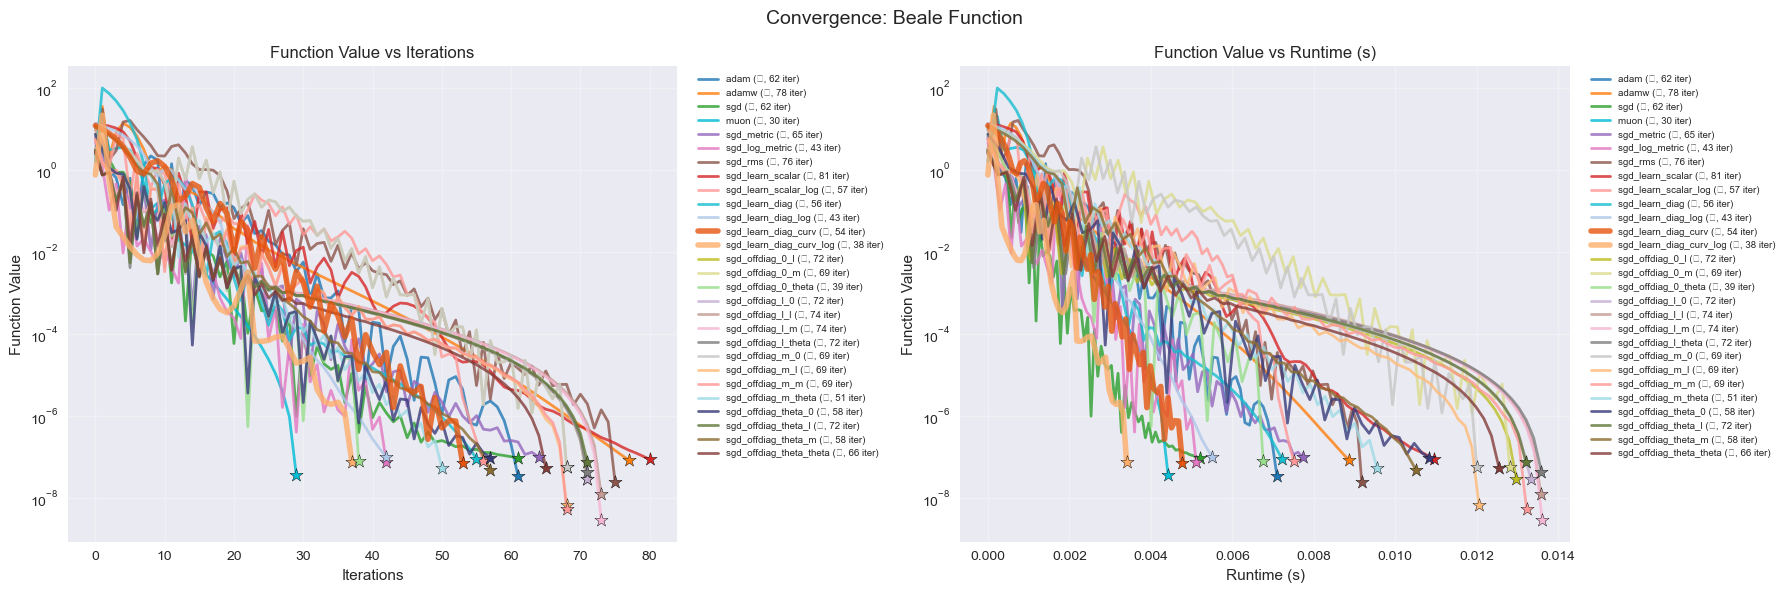


Beale Function Summary:
------------------------------------------------------------
  adam                     : Converged  |   62 iter |  133.1 ms | Final: 3.36e-08
  adamw                    : Converged  |   78 iter |  126.1 ms | Final: 8.25e-08
  sgd                      : Converged  |   62 iter |   68.1 ms | Final: 9.28e-08
  muon                     : Converged  |   30 iter |  131.8 ms | Final: 3.50e-08
  sgd_metric               : Converged  |   65 iter |  137.5 ms | Final: 9.76e-08
  sgd_log_metric           : Converged  |   43 iter |  140.6 ms | Final: 7.30e-08
  sgd_rms                  : Converged  |   76 iter |  165.4 ms | Final: 2.38e-08
  sgd_learn_scalar         : Converged  |   81 iter |  173.3 ms | Final: 8.61e-08
  sgd_learn_scalar_log     : Converged  |   57 iter |  173.2 ms | Final: 8.05e-08
  sgd_learn_diag           : Converged  |   56 iter |  165.8 ms | Final: 8.99e-08
  sgd_learn_diag_log       : Converged  |   43 iter |  170.0 ms | Final: 9.99e-08
  sgd_learn_

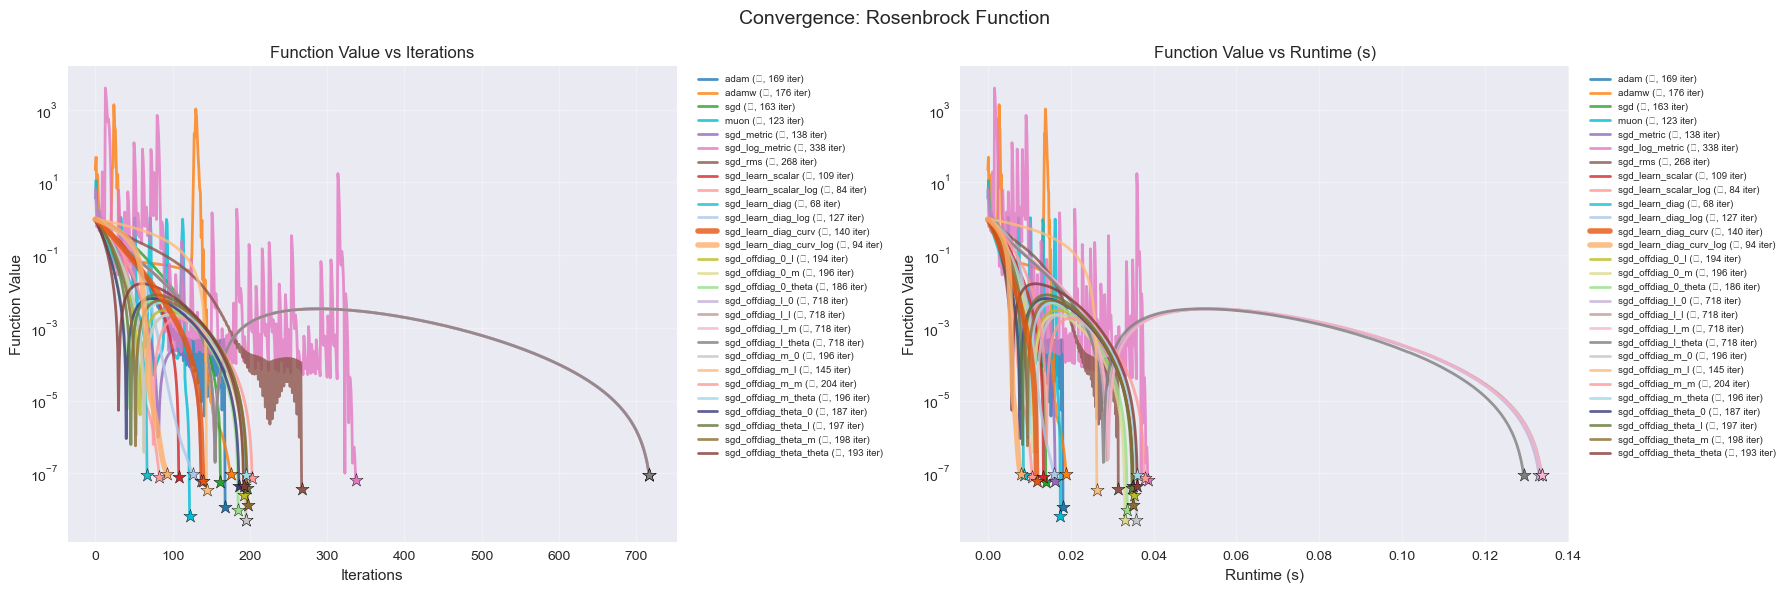


Rosenbrock Function Summary:
------------------------------------------------------------
  adam                     : Converged  |  169 iter |  161.5 ms | Final: 1.20e-08
  adamw                    : Converged  |  176 iter |  127.7 ms | Final: 9.30e-08
  sgd                      : Converged  |  163 iter |   64.2 ms | Final: 5.67e-08
  muon                     : Converged  |  123 iter |  133.2 ms | Final: 6.57e-09
  sgd_metric               : Converged  |  138 iter |  128.6 ms | Final: 6.13e-08
  sgd_log_metric           : Converged  |  338 iter |  153.7 ms | Final: 6.66e-08
  sgd_rms                  : Converged  |  268 iter |  169.6 ms | Final: 3.69e-08
  sgd_learn_scalar         : Converged  |  109 iter |  152.5 ms | Final: 7.92e-08
  sgd_learn_scalar_log     : Converged  |   84 iter |  155.1 ms | Final: 7.95e-08
  sgd_learn_diag           : Converged  |   68 iter |  147.4 ms | Final: 9.18e-08
  sgd_learn_diag_log       : Converged  |  127 iter |  158.2 ms | Final: 9.44e-08
  sgd_l

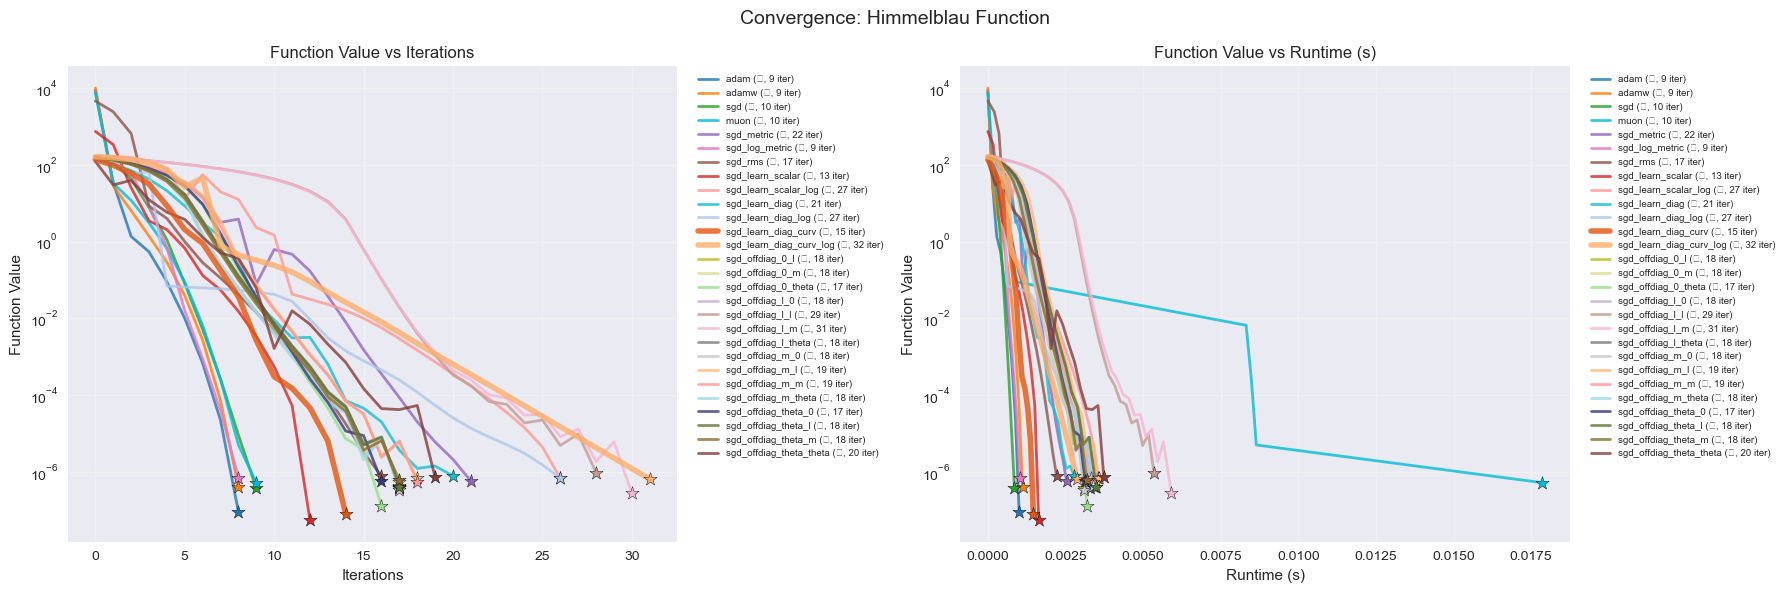


Himmelblau Function Summary:
------------------------------------------------------------
  adam                     : Converged  |    9 iter |  100.8 ms | Final: 8.98e-08
  adamw                    : Converged  |    9 iter |  104.4 ms | Final: 3.97e-07
  sgd                      : Converged  |   10 iter |   54.7 ms | Final: 3.66e-07
  muon                     : Converged  |   10 iter |  135.9 ms | Final: 5.15e-07
  sgd_metric               : Converged  |   22 iter |  122.1 ms | Final: 5.68e-07
  sgd_log_metric           : Converged  |    9 iter |  122.1 ms | Final: 6.96e-07
  sgd_rms                  : Converged  |   17 iter |  148.9 ms | Final: 7.59e-07
  sgd_learn_scalar         : Converged  |   13 iter |  147.5 ms | Final: 5.45e-08
  sgd_learn_scalar_log     : Converged  |   27 iter |  148.2 ms | Final: 6.81e-07
  sgd_learn_diag           : Converged  |   21 iter |  146.1 ms | Final: 7.74e-07
  sgd_learn_diag_log       : Converged  |   27 iter |  149.3 ms | Final: 6.83e-07
  sgd_l

/Users/noah-everett/Library/Mobile Documents/com~apple~CloudDocs/Projects/induced-metric-optimiser/repo/analysis/plots.py:422: UserWarning: Glyph 10007 (\N{BALLOT X}) missing from font(s) Arial.
  plt.tight_layout()
/Users/noah-everett/Library/Mobile Documents/com~apple~CloudDocs/Projects/induced-metric-optimiser/.conda/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 10007 (\N{BALLOT X}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


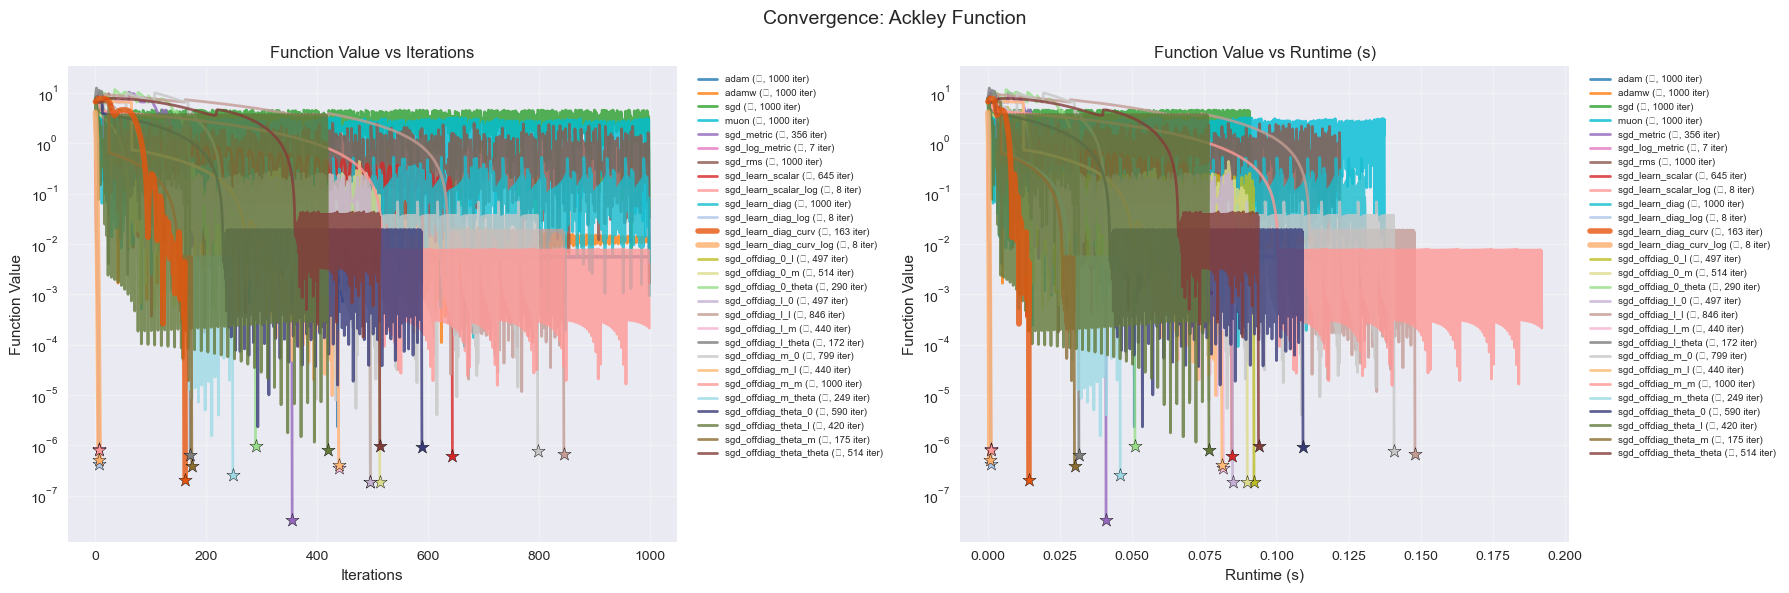


Ackley Function Summary:
------------------------------------------------------------
  adam                     : Failed     | 1000 iter |  278.5 ms | Final: 5.60e-03
  adamw                    : Failed     | 1000 iter |  280.5 ms | Final: 1.32e-02
  sgd                      : Failed     | 1000 iter |  215.0 ms | Final: 3.30e-02
  muon                     : Failed     | 1000 iter |  312.5 ms | Final: 9.33e-04
  sgd_metric               : Converged  |  356 iter |  267.3 ms | Final: 3.26e-08
  sgd_log_metric           : Converged  |    7 iter |  254.4 ms | Final: 8.42e-07
  sgd_rms                  : Failed     | 1000 iter |  321.0 ms | Final: 1.65e-03
  sgd_learn_scalar         : Converged  |  645 iter |  296.9 ms | Final: 6.13e-07
  sgd_learn_scalar_log     : Converged  |    8 iter |  235.7 ms | Final: 8.09e-07
  sgd_learn_diag           : Failed     | 1000 iter |  329.6 ms | Final: 4.27e-03
  sgd_learn_diag_log       : Converged  |    8 iter |  232.1 ms | Final: 4.18e-07
  sgd_learn

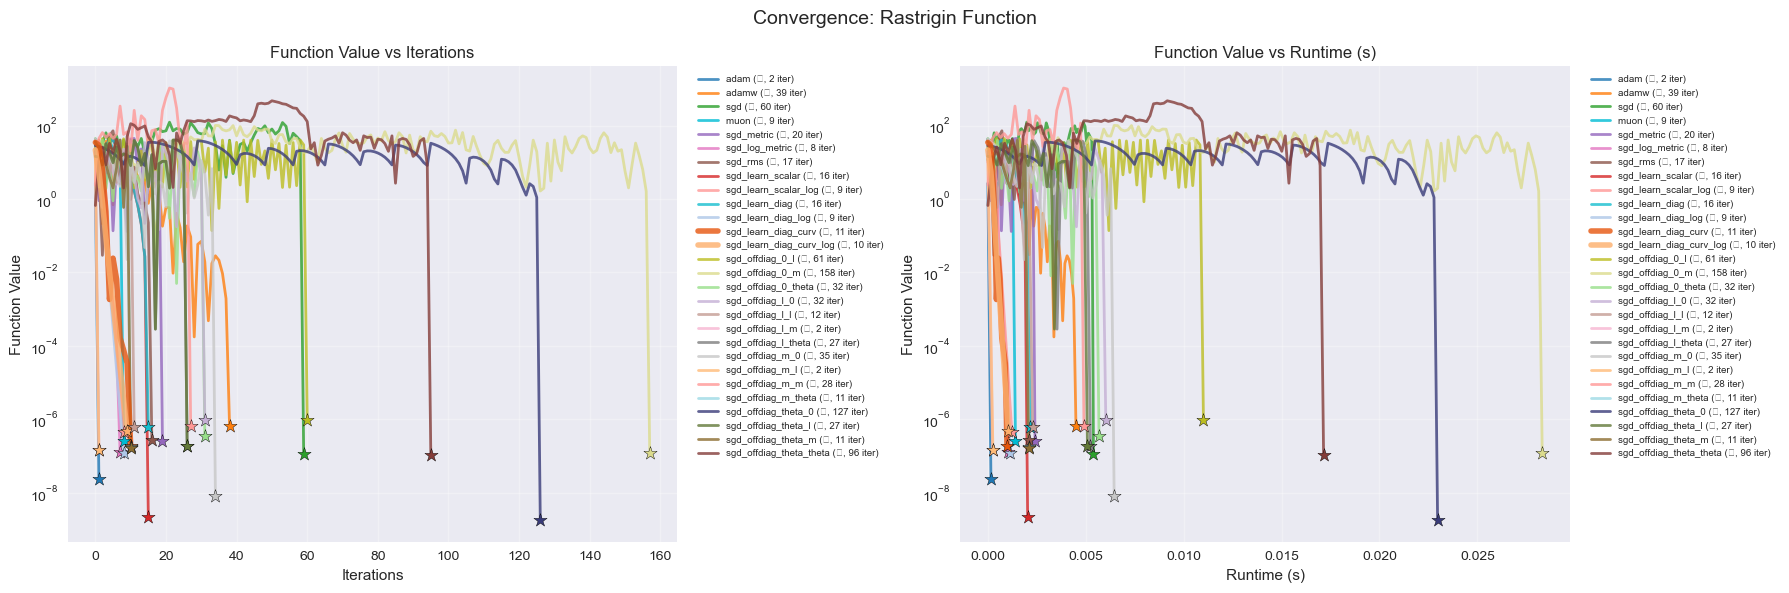


Rastrigin Function Summary:
------------------------------------------------------------
  adam                     : Converged  |    2 iter |  126.6 ms | Final: 2.35e-08
  adamw                    : Converged  |   39 iter |  134.5 ms | Final: 6.62e-07
  sgd                      : Converged  |   60 iter |   90.0 ms | Final: 1.13e-07
  muon                     : Converged  |    9 iter |  138.2 ms | Final: 2.60e-07
  sgd_metric               : Converged  |   20 iter |  154.8 ms | Final: 2.54e-07
  sgd_log_metric           : Converged  |    8 iter |  169.3 ms | Final: 1.30e-07
  sgd_rms                  : Converged  |   17 iter |  179.2 ms | Final: 2.73e-07
  sgd_learn_scalar         : Converged  |   16 iter |  180.4 ms | Final: 2.19e-09
  sgd_learn_scalar_log     : Converged  |    9 iter |  199.9 ms | Final: 4.61e-07
  sgd_learn_diag           : Converged  |   16 iter |  179.8 ms | Final: 6.36e-07
  sgd_learn_diag_log       : Converged  |    9 iter |  190.9 ms | Final: 1.19e-07
  sgd_le

In [7]:
HIGHLIGHT = ["sgd_learn_diag_curv", "sgd_learn_diag_curv_log"]

for func_name in FUNCTIONS:
    best_runs = all_best_runs[func_name]
    if not best_runs:
        continue

    history_data = all_history_data[func_name]

    fig = plot_convergence_curves(
        history_data,
        y_keys=["function_value"],
        x_keys=["epoch", "wall_times"],
        best_runs=best_runs,
        converged_key="converged",
        best_epoch_key="iterations",
        colors=colors,
        highlight=HIGHLIGHT,
        title=f'Convergence: {func_name.title()} Function',
        y_labels={"function_value": "Function Value"},
        x_labels={"epoch": "Iterations", "wall_times": "Runtime (s)"},
    )
    plt.show()

    print_convergence_summary(best_runs, func_name=func_name, optimizers=OPTIMIZERS)

# HP Sensitivity

In [8]:
all_runs_by_func = {}
for func_name in FUNCTIONS:
    task_tag = f"small_examples_{func_name}"
    all_runs_by_func[func_name] = load_all_runs(
        backend=BACKEND,
        optimizers=OPTIMIZERS,
        task_tag=task_tag,
        results_dir=RESULTS_DIR,
        iteration=ITERATION,
    )

Loading all runs for adam...


  adam: 5000 runs
Loading all runs for adamw...


  adamw: 5000 runs
Loading all runs for sgd...


  sgd: 5000 runs
Loading all runs for muon...


  muon: 5000 runs
Loading all runs for sgd_metric...


...

  sgd_offdiag_l_m: 5000 runs
Loading all runs for sgd_offdiag_l_theta...
  sgd_offdiag_l_theta: 5000 runs
Loading all runs for sgd_offdiag_m_0...


  sgd_offdiag_m_0: 5000 runs
Loading all runs for sgd_offdiag_m_l...
  sgd_offdiag_m_l: 5000 runs
Loading all runs for sgd_offdiag_m_m...


  sgd_offdiag_m_m: 5000 runs
Loading all runs for sgd_offdiag_m_theta...
  sgd_offdiag_m_theta: 5000 runs
Loading all runs for sgd_offdiag_theta_0...


  sgd_offdiag_theta_0: 5000 runs
Loading all runs for sgd_offdiag_theta_l...
  sgd_offdiag_theta_l: 5000 runs
Loading all runs for sgd_offdiag_theta_m...


  sgd_offdiag_theta_m: 5000 runs
Loading all runs for sgd_offdiag_theta_theta...
  sgd_offdiag_theta_theta: 5000 runs


In [9]:
# for func_name in FUNCTIONS:
#     for opt in OPTIMIZERS:
#         runs = all_runs_by_func[func_name].get(opt, [])
#         if len(runs) >= 5:
#             fig, axes = plot_hp_sensitivity(
#                 runs, opt,
#                 metric_key='sweep_metric',
#                 direction='minimize',
#             )
#             fig.suptitle(f'{func_name} — {opt}', fontsize=14)
#             plt.show()

# Text-Based Analysis (Paper-Ready Tables)

In [10]:
# Per-function ranking tables and variant comparisons
for func_name in FUNCTIONS:
    br = all_best_runs.get(func_name, {})
    if not br:
        continue
    print_ranking_table(br, metric_key="sweep_metric", direction="minimize",
                        title=f'{func_name.title()} — Optimizer Ranking')
    print_variant_comparison(br, metric_key="sweep_metric", direction="minimize",
                             title=f'{func_name.title()} — Variant Pairs')
    print_offdiag_ranking(br, metric_key="sweep_metric", direction="minimize",
                          title=f'{func_name.title()} — Off-Diagonal Ranking')


Beale — Optimizer Ranking
Rank  Optimizer                     sweep_metric        
--------------------------------------------------------
1     muon                          0.300000            
2     sgd_learn_diag_curv_log       0.380000            
3     sgd_offdiag_0_theta           0.390000            
4     sgd_log_metric                0.430000            
5     sgd_learn_diag_log            0.430000            
6     sgd_offdiag_m_theta           0.510000            
7     sgd_learn_diag_curv           0.540000            
8     sgd_learn_diag                0.560000            
9     sgd_learn_scalar_log          0.570000            
10    sgd_offdiag_theta_m           0.580000            
11    sgd_offdiag_theta_0           0.580000            
12    adam                          0.620000            
13    sgd                           0.620000            
14    sgd_metric                    0.650000            
15    sgd_offdiag_theta_theta       0.660000            
16  

In [11]:
# Overall rankings using ALL runs (not just best) across all functions
print("=" * 80)
print("OVERALL RANKINGS (all runs, all functions)")
print("=" * 80)

# Build summary from all runs
all_rows = []
for func_name in FUNCTIONS:
    for opt, runs in all_runs_by_func.get(func_name, {}).items():
        for r in runs:
            s = r.get("summary", {})
            all_rows.append({
                "function": func_name,
                "optimizer": opt,
                "converged": s.get("converged", False),
                "iterations": s.get("iterations", None),
                "runtime_seconds": s.get("runtime_seconds", None),
                "final_value": s.get("final_value", None),
                "sweep_metric": s.get("sweep_metric", None),
            })

all_runs_df = pd.DataFrame(all_rows)

print(f"\nTotal runs: {len(all_runs_df)}")
print(f"Functions: {all_runs_df['function'].nunique()}")
print(f"Optimizers: {all_runs_df['optimizer'].nunique()}")

print("\n1. BY CONVERGENCE RATE (all runs):")
conv_rate = all_runs_df.groupby('optimizer')['converged'].mean().sort_values(ascending=False)
for i, (opt, rate) in enumerate(conv_rate.items(), 1):
    n = all_runs_df[all_runs_df['optimizer'] == opt].shape[0]
    print(f"  {i:2d}. {opt:30s}: {rate:.1%}  (n={n})")

converged = all_runs_df[all_runs_df['converged'] == True]
if len(converged) > 0:
    print("\n2. BY AVERAGE ITERATIONS (converged runs only):")
    avg_iter = converged.groupby('optimizer')['iterations'].mean().sort_values()
    std_iter = converged.groupby('optimizer')['iterations'].std()
    n_conv = converged.groupby('optimizer').size()
    for i, (opt, val) in enumerate(avg_iter.items(), 1):
        s = std_iter.get(opt, 0)
        n = n_conv.get(opt, 0)
        print(f"  {i:2d}. {opt:30s}: {val:6.1f} +/- {s:5.1f}  (n={n})")

    print("\n3. BY AVERAGE RUNTIME (converged runs only):")
    converged_rt = converged.dropna(subset=['runtime_seconds'])
    if len(converged_rt) > 0:
        converged_rt = converged_rt.copy()
        converged_rt['runtime_ms'] = converged_rt['runtime_seconds'] * 1000
        avg_rt = converged_rt.groupby('optimizer')['runtime_ms'].mean().sort_values()
        for i, (opt, val) in enumerate(avg_rt.items(), 1):
            print(f"  {i:2d}. {opt:30s}: {val:6.1f} ms")

OVERALL RANKINGS (all runs, all functions)



Total runs: 700000
Functions: 5
Optimizers: 28

1. BY CONVERGENCE RATE (all runs):
   1. adam                          : 10.6%  (n=25000)
   2. sgd_learn_scalar_log          : 10.3%  (n=25000)
   3. muon                          : 9.2%  (n=25000)
   4. sgd                           : 9.2%  (n=25000)
   5. adamw                         : 7.6%  (n=25000)
   6. sgd_learn_diag_curv_log       : 6.6%  (n=25000)
   7. sgd_learn_diag_log            : 5.9%  (n=25000)
   8. sgd_log_metric                : 5.9%  (n=25000)
   9. sgd_rms                       : 4.2%  (n=25000)
  10. sgd_learn_scalar              : 3.7%  (n=25000)
  11. sgd_learn_diag_curv           : 3.0%  (n=25000)
  12. sgd_metric                    : 2.4%  (n=25000)
  13. sgd_learn_diag                : 2.0%  (n=25000)
  14. sgd_offdiag_0_theta           : 1.1%  (n=25000)
  15. sgd_offdiag_m_0               : 1.0%  (n=25000)
  16. sgd_offdiag_m_theta           : 1.0%  (n=25000)
  17. sgd_offdiag_theta_theta       : 1.0%  (n=250

In [12]:
# Statistical variant comparison and HP sensitivity (across all functions)
for func_name in FUNCTIONS:
    ar = all_runs_by_func.get(func_name, {})
    if not ar:
        continue
    print_variant_comparison_allruns(ar, metric_key="sweep_metric", direction="minimize",
                                     title=f'{func_name.title()} — Variant Comparison (Mann-Whitney U)')

# HP sensitivity for curv variants (pooled across functions)
for opt in ['sgd_learn_diag_curv', 'sgd_learn_diag_curv_log']:
    pooled = []
    for func_name in FUNCTIONS:
        pooled.extend(all_runs_by_func.get(func_name, {}).get(opt, []))
    if len(pooled) >= 10:
        print_hp_sensitivity_table(pooled, metric_key="sweep_metric",
                                   title=f'HP Sensitivity (pooled across functions) — {opt}')


Beale — Variant Comparison (Mann-Whitney U)
Comparison                    Base med   Var med    n_base  n_var   U           r       Effect      p-value   Sig?  
--------------------------------------------------------------------------------------------------------------------
log embedding                 116.460730 111.358659 4999    5000    10798902    +0.136  small       0.0000    ***   
curvature correction          116.460730 119.712170 5000    5000    13094954    -0.048  negligible  1.0000          
curvature correction (log)    111.358659 118.684817 5000    4999    13889286    -0.111  small       1.0000          
log embedding (curv)          119.712170 118.684817 5000    5000    11581030    +0.074  negligible  0.0000    ***   
diagonal vs scalar            116.306270 116.460730 5000    5000    12915933    -0.033  negligible  0.9980          
diagonal vs scalar (log)      112.867836 111.358659 4999    5000    12517346    -0.002  negligible  0.5547          


Rosenbrock — Vari

curvature correction          117.959728 117.959742 5000    5000    12600299    -0.008  negligible  0.7564          
curvature correction (log)    117.959796 117.959879 5000    5000    12715371    -0.017  negligible  0.9322          
log embedding (curv)          117.959742 117.959879 5000    5000    12698053    -0.016  negligible  0.9150          
diagonal vs scalar            117.959749 117.959728 5000    5000    12412808    +0.007  negligible  0.2729          
diagonal vs scalar (log)      117.959666 117.959796 5000    5000    14022783    -0.122  small       1.0000          


HP Sensitivity (pooled across functions) — sgd_learn_diag_curv
HP                       Spearman rho   p-value     Sig?  Direction   
----------------------------------------------------------------------


learning_rate            -0.166         0.0000      ***   lower=better
metric_clip              +0.040         0.0000      ***   higher=better
xi                       +0.036         0.0000      ***   higher=better
momentum                 -0.031         0.0000      ***   lower=better
beta                     -0.027         0.0000      ***   lower=better
metric_lr                +0.025         0.0001      ***   higher=better
weight_decay             +0.020         0.0013      **    higher=better
curv_tau                 +0.006         0.3490            higher=better
metric_reg               +0.002         0.7362            higher=better
curv_beta                -0.000         0.9737            lower=better


HP Sensitivity (pooled across functions) — sgd_learn_diag_curv_log
HP                       Spearman rho   p-value     Sig?  Direction   
----------------------------------------------------------------------


learning_rate            -0.219         0.0000      ***   lower=better
xi                       -0.076         0.0000      ***   lower=better
metric_clip              +0.053         0.0000      ***   higher=better
weight_decay             +0.047         0.0000      ***   higher=better
momentum                 -0.015         0.0186      *     lower=better
curv_tau                 +0.009         0.1404            higher=better
beta                     -0.006         0.3234            lower=better
curv_beta                -0.006         0.3652            lower=better
metric_reg               +0.003         0.6200            higher=better
metric_lr                +0.003         0.6586            higher=better



/Users/noah-everett/Library/Mobile Documents/com~apple~CloudDocs/Projects/induced-metric-optimiser/repo/analysis/tables.py:341: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, p = spearmanr(vals, perf)


In [13]:
# Statistical variant comparison (all runs, pooled across functions)
# Pool runs from all functions for each optimizer
pooled_runs = {}
for func_name in FUNCTIONS:
    for opt, runs in all_runs_by_func.get(func_name, {}).items():
        pooled_runs.setdefault(opt, []).extend(runs)

print_variant_comparison_allruns(pooled_runs, metric_key="sweep_metric", direction="minimize",
                                 title='Small Examples (pooled) — Variant Comparison (Mann-Whitney U)')

# HP sensitivity for key variants (pooled)
for opt in ['sgd_learn_diag_curv', 'sgd_learn_diag_curv_log', 'sgd_learn_diag', 'adam', 'sgd']:
    runs = pooled_runs.get(opt, [])
    if len(runs) >= 10:
        print_hp_sensitivity_table(runs, metric_key="sweep_metric",
                                   title=f'HP Sensitivity (pooled) — {opt}')


Small Examples (pooled) — Variant Comparison (Mann-Whitney U)
Comparison                    Base med   Var med    n_base  n_var   U           r       Effect      p-value   Sig?  
--------------------------------------------------------------------------------------------------------------------
log embedding                 116.591134 116.580865 24999   25000   295000877   +0.056  negligible  0.0000    ***   
curvature correction          116.591134 116.591358 25000   25000   311730648   +0.002  negligible  0.3168          
curvature correction (log)    116.580865 116.590537 25000   24999   319709676   -0.023  negligible  1.0000          


log embedding (curv)          116.591358 116.590537 25000   25000   303419775   +0.029  negligible  0.0000    ***   
diagonal vs scalar            116.570607 116.591134 25000   25000   329808092   -0.055  negligible  1.0000          
diagonal vs scalar (log)      116.559681 116.580865 24999   25000   340230552   -0.089  negligible  1.0000          


HP Sensitivity (pooled) — sgd_learn_diag_curv
HP                       Spearman rho   p-value     Sig?  Direction   
----------------------------------------------------------------------


learning_rate            -0.166         0.0000      ***   lower=better
metric_clip              +0.040         0.0000      ***   higher=better
xi                       +0.036         0.0000      ***   higher=better
momentum                 -0.031         0.0000      ***   lower=better
beta                     -0.027         0.0000      ***   lower=better
metric_lr                +0.025         0.0001      ***   higher=better
weight_decay             +0.020         0.0013      **    higher=better
curv_tau                 +0.006         0.3490            higher=better
metric_reg               +0.002         0.7362            higher=better
curv_beta                -0.000         0.9737            lower=better


HP Sensitivity (pooled) — sgd_learn_diag_curv_log
HP                       Spearman rho   p-value     Sig?  Direction   
----------------------------------------------------------------------


learning_rate            -0.219         0.0000      ***   lower=better
xi                       -0.076         0.0000      ***   lower=better
metric_clip              +0.053         0.0000      ***   higher=better
weight_decay             +0.047         0.0000      ***   higher=better
momentum                 -0.015         0.0186      *     lower=better
curv_tau                 +0.009         0.1404            higher=better
beta                     -0.006         0.3234            lower=better
curv_beta                -0.006         0.3652            lower=better
metric_reg               +0.003         0.6200            higher=better
metric_lr                +0.003         0.6586            higher=better


HP Sensitivity (pooled) — sgd_learn_diag
HP                       Spearman rho   p-value     Sig?  Direction   
----------------------------------------------------------------------
learning_rate            -0.134         0.0000      ***   lower=better
metric_clip              +0.0

learning_rate            -0.269         0.0000      ***   lower=better
beta1                    -0.054         0.0000      ***   lower=better
beta2                    -0.030         0.0000      ***   lower=better
eps                      +0.005         0.3871            higher=better


HP Sensitivity (pooled) — sgd
HP                       Spearman rho   p-value     Sig?  Direction   
----------------------------------------------------------------------
momentum                 -0.063         0.0000      ***   lower=better
learning_rate            -0.034         0.0000      ***   lower=better



# Budget-Aware Statistical Analysis

Bootstrap CIs on best-run, top-k comparison, robustness metrics, and
best-of-budget incumbent curves. These use the pooled runs across all
test functions to control for the maximum order statistic problem.

In [14]:
# Bootstrap CI on best-run (pooled across functions)
bootstrap_best_run_ci(pooled_runs, metric_key="sweep_metric", direction="minimize",
                      title=f'Small Examples (pooled, itr {ITERATION}) — Bootstrap 95% CI on Best Run')

# Top-k mean comparison (pooled)
print_topk_comparison(pooled_runs, metric_key="sweep_metric", direction="minimize",
                      title=f'Small Examples (pooled, itr {ITERATION}) — Top-k Mean Comparison')

# Robustness table (pooled)
print_robustness_table(pooled_runs, metric_key="sweep_metric", direction="minimize",
                       title=f'Small Examples (pooled, itr {ITERATION}) — Robustness Metrics')


Small Examples (pooled, itr 3) — Bootstrap 95% CI on Best Run
Optimizer                     Best        CI lo       CI hi       n_runs  
--------------------------------------------------------------------------


adam                          0.020000    0.020000    0.100000    25000   


adamw                         0.090000    0.090000    0.130000    25000   


sgd                           0.100000    0.100000    0.110000    18969   


muon                          0.090000    0.090000    0.110000    25000   


...

sgd_offdiag_theta_l           0.180000    0.180000    0.400001    20068   


sgd_offdiag_theta_m           0.110000    0.110000    0.350001    20429   


sgd_offdiag_theta_theta       0.200001    0.200001    0.360000    21114   


Small Examples (pooled, itr 3) — Top-k Mean Comparison
Optimizer                     top-1         top-5         top-10        top-50        n_runs  
----------------------------------------------------------------------------------------------


adam                          0.020000      0.080000      0.095000      0.130600      25000   
sgd_offdiag_m_l               0.020000      0.244000      0.412000      1.102400      20492   
sgd_offdiag_l_m               0.020000      0.320000      0.509000      1.383201      19270   
sgd_log_metric                0.070001      0.084000      0.095000      0.137400      25000   
sgd_learn_diag_log            0.080000      0.092000      0.098000      0.126200      24999   
sgd_learn_diag_curv_log       0.080001      0.088000      0.094000      0.122800      25000   
sgd_learn_scalar_log          0.080001      0.090000      0.099000      0.134800      25000   
muon                          0.090000      0.102000      0.106000      0.127600      25000   
adamw                         0.090000      0.118000      0.126000      0.171600      25000   
sgd                           0.100000      0.110000      0.120000      0.146800      18969   
sgd_offdiag_theta_m           0.110000      0.2500


Small Examples (pooled, itr 3) — Robustness Metrics
  Failure threshold: 279.988522 (> = failure)
Optimizer                     Median      Q1          Q3          IQR         Fail%   n       
----------------------------------------------------------------------------------------------
sgd                           116.559645  110.232255  117.971299  7.739044    4.1%    18969   
sgd_learn_scalar_log          116.559681  110.049103  118.421354  8.372251    3.8%    25000   
adam                          116.559893  110.328727  120.409056  10.080329   1.6%    25000   
adamw                         116.559977  110.453970  120.544463  10.090493   1.3%    25000   
muon                          116.561122  110.374201  121.301552  10.927351   1.9%    25000   
sgd_learn_scalar              116.570607  110.743583  123.417756  12.674174   3.2%    25000   
sgd_learn_diag_log            116.580865  110.666473  123.019027  12.352554   3.4%    24999   
sgd_learn_diag_curv_log       116.590537  110.

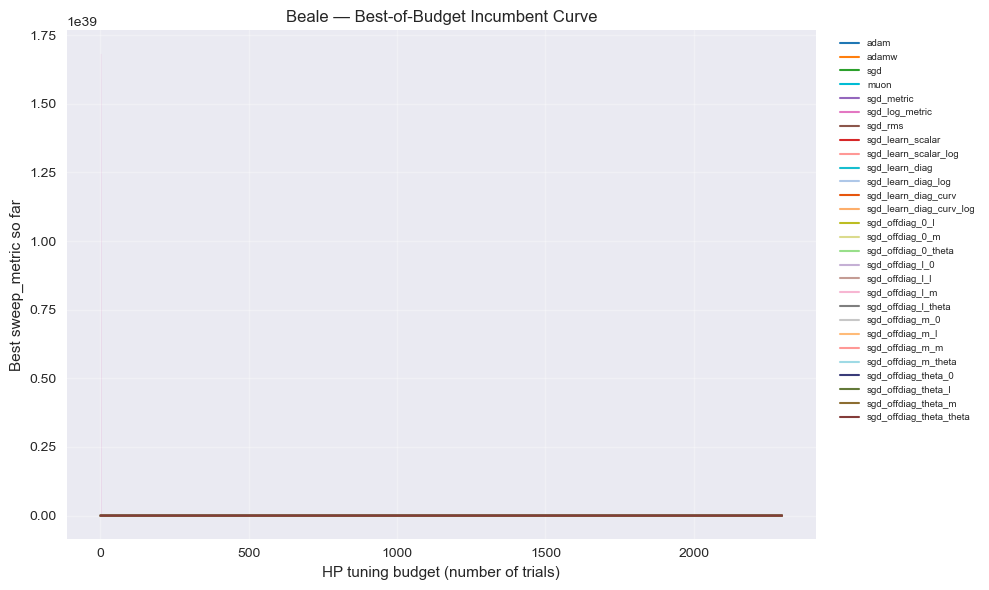

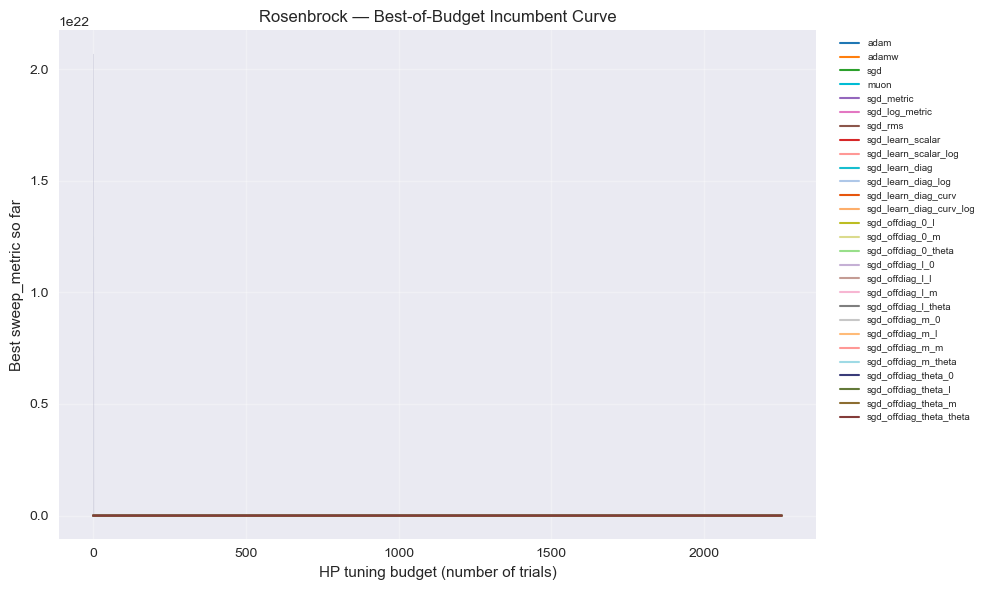

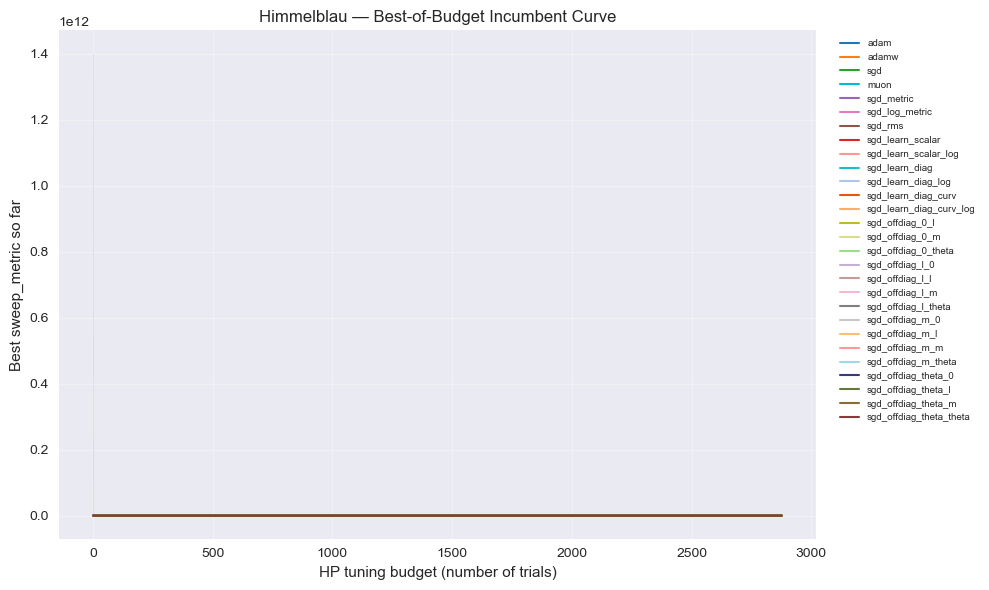

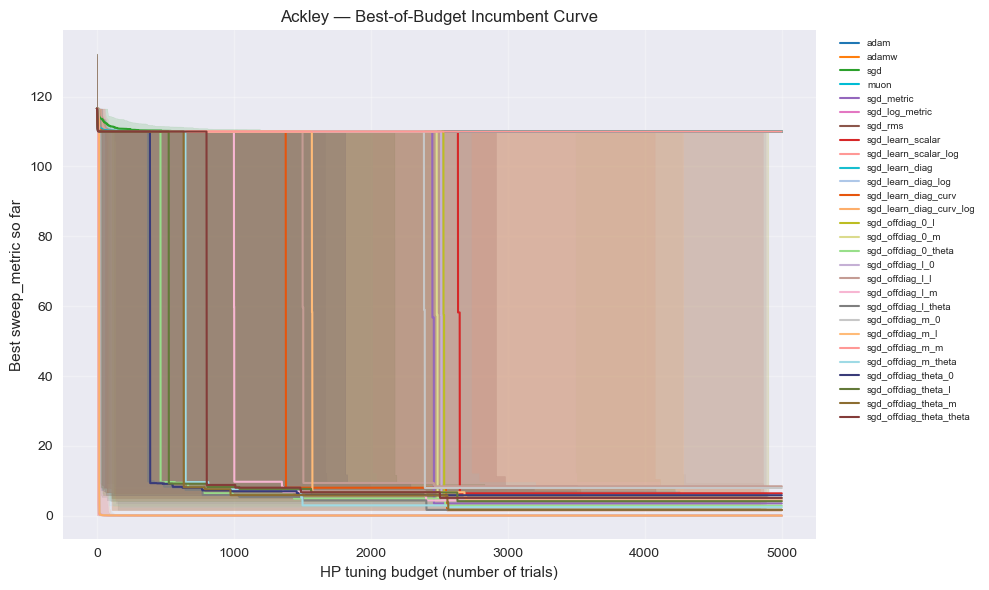

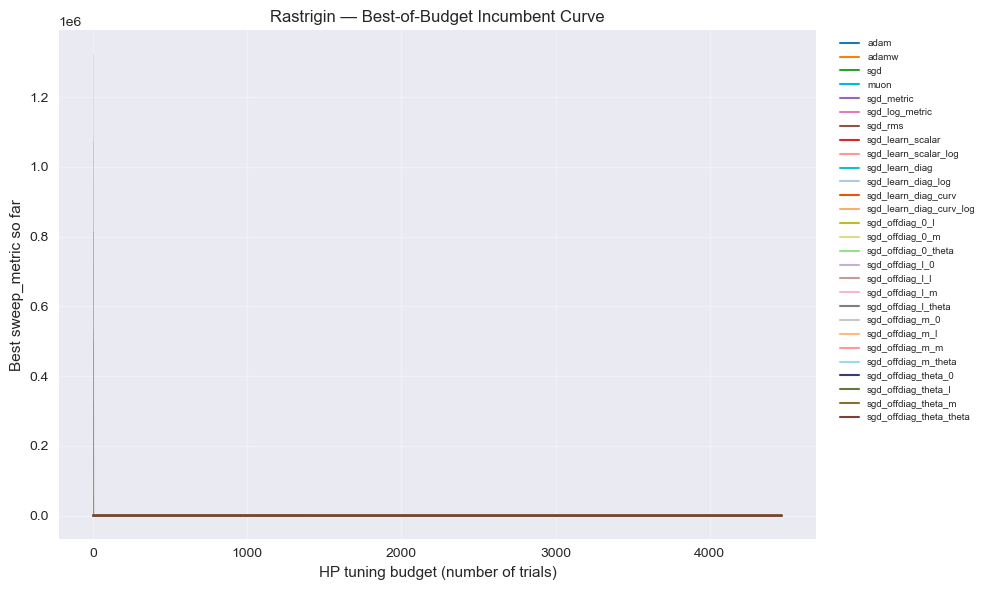

In [15]:
# Best-of-budget incumbent curves (per function)
for func_name in FUNCTIONS:
    ar = all_runs_by_func.get(func_name, {})
    if not ar:
        continue
    fig = plot_best_of_budget(ar, metric_key="sweep_metric", direction="minimize",
                              title=f'{func_name.title()} — Best-of-Budget Incumbent Curve')
    plt.show()

# Best Hyperparameters


In [16]:
# Print and save best hyperparameters per function
all_hp_rows = []

for func_name in FUNCTIONS:
    best_runs = all_best_runs[func_name]
    if not best_runs:
        continue

    print(f"\n{'=' * 60}")
    print(f"{func_name.upper()} FUNCTION")
    print(f"{'=' * 60}")
    print_best_hyperparameters(best_runs)

    for opt, run_info in best_runs.items():
        row = {
            'function': func_name,
            'optimizer': opt,
            'run_name': run_info.get('name', 'unknown'),
        }
        row.update(run_info.get('config', {}))
        row.update(run_info.get('summary', {}))
        all_hp_rows.append(row)

df = pd.DataFrame(all_hp_rows)
filename = f'best_hyperparameters_SmallExamples_itr_{ITERATION}.csv'
df.to_csv(filename, index=False)
print(f"\nSaved all hyperparameters to {filename}")
df


BEALE FUNCTION
Hyperparameters for Best Runs

ADAM:
  Run name: run_1629
  Config:
    learning_rate: 0.8266274631777079
    beta1: 0.7198911816427371
    beta2: 0.9960541587603314
    eps: 4.195371185029335e-10
    max_iterations: 1000
  sweep_metric: 0.620000
----------------------------------------

ADAMW:
  Run name: run_3114
  Config:
    learning_rate: 1.3102394500926218
    beta1: 0.5648473264004725
    beta2: 0.9755792876169287
    eps: 6.07419514470729e-10
    weight_decay: 6.837059641173795e-06
    max_iterations: 1000
  sweep_metric: 0.780000
----------------------------------------

SGD:
  Run name: run_649
  Config:
    learning_rate: 0.028510953829434738
    momentum: 0.6994109692220322
    max_iterations: 1000
  sweep_metric: 0.620000
----------------------------------------

MUON:
  Run name: run_4117
  Config:
    learning_rate: 0.9063525064620815
    adam_b1: 0.7442939555643896
    adam_b2: 0.9323668544034721
    eps: 4.86548276777392e-09
    beta: 0.8645195837779095

,function,optimizer,run_name,learning_rate,beta1,beta2,eps,max_iterations,total_training_time_sec,total_training_time_min,...,xi,beta_rms,metric_lr,metric_reg,metric_clip,curv_beta,curv_tau,gamma,base_mode,use_momentum_for_update
0,beale,adam,run_1629,0.826627,0.719891,0.996054,4.195371e-10,1000,0.143453,0.002391,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,beale,adamw,run_3114,1.310239,0.564847,0.975579,6.074195e-10,1000,0.138436,0.002307,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,beale,sgd,run_649,0.028511,NaN,NaN,NaN,1000,0.076878,0.001281,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,beale,muon,run_4117,0.906353,NaN,NaN,4.865483e-09,1000,0.138427,0.002307,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,beale,sgd_metric,run_1511,0.079879,NaN,NaN,NaN,1000,0.148088,0.002468,...,0.002650,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
135,rastrigin,sgd_offdiag_m_theta,run_3415,0.044423,NaN,NaN,NaN,1000,0.168270,0.002804,...,0.003442,NaN,NaN,NaN,NaN,NaN,NaN,0.002072,momentum,True
136,rastrigin,sgd_offdiag_theta_0,run_1877,0.646335,NaN,NaN,NaN,1000,0.202814,0.003380,...,0.203773,NaN,NaN,NaN,NaN,NaN,NaN,0.000221,grad,True
137,rastrigin,sgd_offdiag_theta_l,run_1711,0.061822,NaN,NaN,NaN,1000,0.182203,0.003037,...,0.000581,NaN,NaN,NaN,NaN,NaN,NaN,1.674757,grad,True
138,rastrigin,sgd_offdiag_theta_m,run_3415,0.044423,NaN,NaN,NaN,1000,0.171347,0.002856,...,0.003442,NaN,NaN,NaN,NaN,NaN,NaN,0.002072,momentum,True


# Optimizer Diagnostics

Internal state diagnostics (requires `--diagnostics` flag during sweep).
Skips gracefully if no diagnostic data is present.

In [17]:
diag_keys = (
    DIAG_KEYS_METRIC_SCALE + DIAG_KEYS_LEARNABLE +
    DIAG_KEYS_CURVATURE + DIAG_KEYS_TRAINING + DIAG_KEYS_OFFDIAG
)

for func_name in FUNCTIONS:
    best_runs = all_best_runs.get(func_name, {})
    if not best_runs:
        continue
    diag_data = extract_history(BACKEND, best_runs, diag_keys)

    plot_diagnostic_curves(diag_data, DIAG_KEYS_TRAINING,
        title=f"{func_name}: Training-Level Diagnostics")
    plt.show()

    plot_diagnostic_curves(diag_data, DIAG_KEYS_METRIC_SCALE,
        title=f"{func_name}: Metric Scale")
    plt.show()

    plot_diagnostic_curves(diag_data, DIAG_KEYS_LEARNABLE,
        title=f"{func_name}: Learnable Metric")
    plt.show()

    plot_effective_lr_comparison(diag_data,
        title=f"{func_name}: Effective LR Comparison")
    plt.show()


Processing adam...
Processing adamw...
Processing sgd...
Processing muon...
Processing sgd_metric...
Processing sgd_log_metric...
Processing sgd_rms...
Processing sgd_learn_scalar...
Processing sgd_learn_scalar_log...
Processing sgd_learn_diag...
Processing sgd_learn_diag_log...
Processing sgd_learn_diag_curv...
Processing sgd_learn_diag_curv_log...
Processing sgd_offdiag_0_l...
Processing sgd_offdiag_0_m...
Processing sgd_offdiag_0_theta...
Processing sgd_offdiag_l_0...
Processing sgd_offdiag_l_l...
Processing sgd_offdiag_l_m...
Processing sgd_offdiag_l_theta...
Processing sgd_offdiag_m_0...
Processing sgd_offdiag_m_l...
Processing sgd_offdiag_m_m...
Processing sgd_offdiag_m_theta...
Processing sgd_offdiag_theta_0...
Processing sgd_offdiag_theta_l...
Processing sgd_offdiag_theta_m...
Processing sgd_offdiag_theta_theta...
  [skip] No data for requested keys in: beale: Training-Level Diagnostics
  [skip] No data for requested keys in: beale: Metric Scale
  [skip] No data for requested k